In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os
import glob
from IPython.display import display, HTML
from scipy.signal import savgol_filter
from spikes_proxy_funcs import datasets, processing, rate_analysis

In [2]:
data = datasets.load_selected_data(num_datasets='all', num_neurons_per_dataset='all')

In [3]:
new_rate = 100 # Hz
upsampled_results = []

In [4]:
for ds_name, recordings in data.items():
    for i, rec in enumerate(recordings):
        times = rec['t']
        dff = rec['dff']
        spikes = rec['spikes']
        
        # Upsample using our new helper function
        u_sig, u_spk = processing.upsample(times, dff, spikes, new_rate=new_rate, do_plot=False)
        
        upsampled_results.append({
            'dataset': ds_name,
            'neuron_idx': i,
            'signal': u_sig,
            'spikes': u_spk
        })

In [5]:
import pandas as pd
import numpy as np
from IPython.display import display, HTML

summary_list = []

print("Generating Dataset Summary Table...")

for res in upsampled_results:
    ds_name = res['dataset']
    idx = res['neuron_idx']
    
    # --- Retrieve Signals ---
    u_sig = res['signal']
    u_spk = res['spikes']
    
    # --- Retrieve Original Metadata ---
    # Access original 'data' dict to get the original frame rate
    # (Safe lookup in case 'data' variable isn't perfectly synced)
    if 'data' in globals() and ds_name in data and idx < len(data[ds_name]):
        orig_fps = data[ds_name][idx].get('frame_rate', np.nan)
    else:
        orig_fps = np.nan
    
    # --- Calculate Features ---
    # 1. Duration (seconds)
    duration = len(u_sig) / new_rate
    
    # 2. Number of Spikes
    n_spikes = np.sum(u_spk > 0.5)
    
    # 3. Firing Rate (Hz)
    firing_rate = n_spikes / duration if duration > 0 else 0
    
    # 4. Signal Stats
    sig_mean = np.mean(u_sig)
    sig_std = np.std(u_sig)
    
    # --- Append to List ---
    summary_list.append({
        'Dataset': ds_name,
        'Neuron_Idx': idx,
        'Original_FPS': orig_fps,
        'Upsampled_FPS': new_rate,
        'Duration_s': round(duration, 2),
        'Num_Spikes': int(n_spikes),
        'Firing_Rate_Hz': round(firing_rate, 2),
        'Signal_Mean': round(sig_mean, 4),
        'Signal_Std': round(sig_std, 4)
    })

# Create DataFrame
df_summary = pd.DataFrame(summary_list)

# 1. Temporarily show ALL rows (disable truncation) otherwise to_html truncates
pd.set_option('display.max_rows', None)

print(f"Total Neurons: {len(df_summary)}")

# 2. Display with scrollbar (height: 300px gives approx. 10 rows visible)
display(HTML("<div style='height: 500px; overflow: auto; width: 100%'>" + 
             df_summary.to_html() + 
             "</div>"))

# 3. Reset option (optional, so other cells behave normally)
pd.reset_option('display.max_rows')

# Optional: Averages Table
print("\n--- Averages by Dataset ---")
display(df_summary.groupby('Dataset')[['Original_FPS', 'Firing_Rate_Hz', 'Duration_s']].mean().round(2))

Generating Dataset Summary Table...
Total Neurons: 1157


,Dataset,Neuron_Idx,Original_FPS,Upsampled_FPS,Duration_s,Num_Spikes,Firing_Rate_Hz,Signal_Mean,Signal_Std
0,DS01-OGB1-m-V1,0,12.175000,100,470.30,359,0.76,0.0576,0.0527
1,DS01-OGB1-m-V1,1,12.022000,100,96.81,44,0.45,0.0630,0.0577
2,DS01-OGB1-m-V1,2,11.467000,100,370.79,293,0.79,0.0468,0.0430
3,DS01-OGB1-m-V1,3,10.926000,100,212.51,587,2.76,0.0474,0.0386
4,DS01-OGB1-m-V1,4,12.175000,100,257.08,326,1.27,0.0651,0.0559
5,DS01-OGB1-m-V1,5,11.952000,100,336.84,362,1.07,0.0488,0.0519
6,DS01-OGB1-m-V1,6,9.743000,100,543.97,1381,2.54,0.0718,0.0658
7,DS01-OGB1-m-V1,7,11.607000,100,320.49,218,0.68,0.0515,0.0475
8,DS01-OGB1-m-V1,8,11.607000,100,274.13,527,1.92,0.0681,0.0810
9,DS01-OGB1-m-V1,9,10.667000,100,630.35,251,0.40,0.0420,0.0365



--- Averages by Dataset ---


,Original_FPS,Firing_Rate_Hz,Duration_s
Dataset,,,
DS01-OGB1-m-V1,11.45,1.80,415.55
DS02-OGB1-2-m-V1,15.46,0.21,148.46
DS03-Cal520-m-S1,500.00,1.06,7.92
DS04-OGB1-zf-pDp,7.71,0.54,108.81
DS05-Cal520-zf-pDp,7.81,0.78,117.84
DS06-GCaMP6f-zf-aDp,30.05,2.11,119.83
DS07-GCaMP6f-zf-dD,30.05,1.38,119.81
DS08-GCaMP6f-zf-OB,30.05,3.95,118.09
DS09-GCaMP6f-m-V1,60.06,0.56,234.80


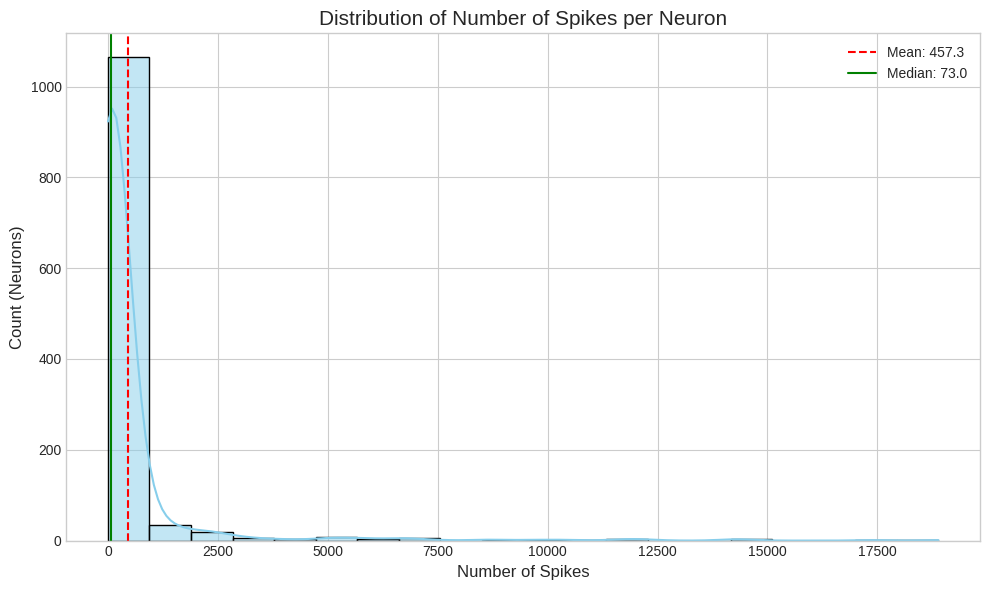

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for nicer plots (optional)
# Using seaborn-v0_8 style to avoid warnings if seaborn is updated
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    try:
        plt.style.use('seaborn-whitegrid')
    except:
        pass # Fallback to default

plt.figure(figsize=(10, 6))

# Plot Histogram with KDE (Kernel Density Estimate)
sns.histplot(df_summary['Num_Spikes'], kde=True, bins=20, color='skyblue', edgecolor='black')

plt.title('Distribution of Number of Spikes per Neuron', fontsize=15)
plt.xlabel('Number of Spikes', fontsize=12)
plt.ylabel('Count (Neurons)', fontsize=12)

# Verify if we have varied data
plt.axvline(df_summary['Num_Spikes'].mean(), color='red', linestyle='--', label=f"Mean: {df_summary['Num_Spikes'].mean():.1f}")
plt.axvline(df_summary['Num_Spikes'].median(), color='green', linestyle='-', label=f"Median: {df_summary['Num_Spikes'].median():.1f}")

plt.legend()
plt.tight_layout()
plt.show()

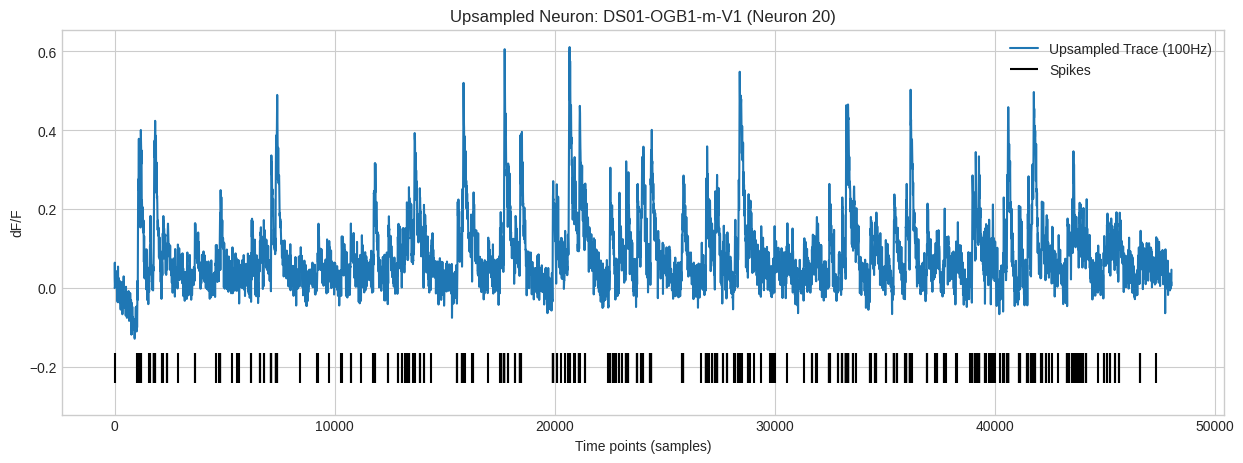

In [7]:
example = upsampled_results[20]
u_sig = example['signal']
u_spk = example['spikes']

plt.figure(figsize=(15, 5))
plt.plot(u_sig, label=f'Upsampled Trace ({new_rate}Hz)')
    
# Calculate global range to position spikes nicely below the signal
mx = np.max(u_sig)
mn = np.min(u_sig)
rng = mx - mn
    
# Plot spikes using eventplot
plt.eventplot(u_spk, lineoffsets=mn - rng*0.1, linelengths=rng*0.1, color='k', label='Spikes')
    
plt.title(f"Upsampled Neuron: {example['dataset']} (Neuron {example['neuron_idx']})")
plt.xlabel("Time points (samples)")
plt.ylabel("dF/F")
plt.legend()
plt.show()

In [8]:
# Analysis Settings
window_len = 51
poly_order = 3
cut_win = 10
new_rate = 100 

results = []

print("Generating final summary table with Signal Length and Duration...")

for res in upsampled_results:
    u_sig = res['signal'].copy()
    u_spk = res['spikes']
    
    # 1. Standardize Signal (Handle NaNs)
    if np.any(np.isnan(u_sig)):
        mask = np.isnan(u_sig)
        if not np.all(mask):
            u_sig[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), u_sig[~mask])
        else: 
            continue

    # 2. Derivative & Smoothing
    if len(u_sig) < window_len: 
        continue
    sig_smooth = savgol_filter(u_sig, window_length=window_len, polyorder=poly_order, deriv=0)
    der_smooth = savgol_filter(u_sig, window_length=window_len, polyorder=poly_order, deriv=1)
    
    # 3. Tau Estimation (Generic Cut Spikes + Linear Fit)
    # Uses cut_spikes to isolate decay bulk before fitting
    sig_fit, der_fit, _ = rate_analysis.cut_spikes(u_spk, sig_smooth, der_smooth, win_len=cut_win)
    
    try:
        if len(sig_fit) > 2:
            # Linear fit on the 'decay-only' portion of the signal
            slope, _ = np.polyfit(sig_fit, der_fit, 1)
            tau = -1.0 / slope if slope < 0 else np.nan
        else: 
            tau = np.nan
    except: 
        tau = np.nan
        
    # 4. CV2 Calculation (Generic function handles empty/sparse spikes)
    cv2_val = rate_analysis.calculate_cv2(u_spk)
    
    # 5. Metadata Calculation
    sig_len = len(u_sig)
    duration = sig_len / new_rate
    
    results.append({
        'Dataset': res['dataset'],
        'Neuron_Idx': res['neuron_idx'],
        'Signal_Length_Frames': sig_len,
        'Duration_s': round(duration, 2),
        'Num_Spikes': len(u_spk),
        'Estimated_Tau': round(tau, 4) if not np.isnan(tau) else "N/A",
        'CV2': round(cv2_val, 4) if not np.isnan(cv2_val) else "N/A",
        'Firing_Rate_Hz': round(len(u_spk) / duration, 2) if duration > 0 else 0
    })

# Create and Sort Table
df_final = pd.DataFrame(results).sort_values(by='Num_Spikes', ascending=False)

# Display
pd.set_option('display.max_rows', None)
display(HTML("<h3>Final Analysis (Sorted by Spike Count)</h3>"))
display(HTML("<div style='height: 500px; overflow: auto; width: 100%; border: 1px solid #ddd;'>" + 
             df_final.to_html(index=False) + 
             "</div>"))
pd.reset_option('display.max_rows')

# Optional: Print Global Means
valid_numeric = df_final[['Estimated_Tau', 'CV2']].apply(pd.to_numeric, errors='coerce')
print("\n--- Global Analysis Summary ---")
print(f"Total Neurons: {len(df_final)}")
print(valid_numeric.describe().loc[['mean', 'std', '50%']].round(4))

Generating final summary table with Signal Length and Duration...


/home/mjoudy/Documents/codes/Cascade/spikes_proxy_funcs/rate_analysis.py:120: RuntimeWarning: invalid value encountered in divide
  return np.mean(2 * np.abs(isi[1:] - isi[:-1]) / (isi[1:] + isi[:-1]))
/home/mjoudy/miniconda3/envs/phd_conda/lib/python3.12/site-packages/numpy/lib/_polynomial_impl.py:665: RuntimeWarning: invalid value encountered in divide
  lhs /= scale


 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  5 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value


Dataset,Neuron_Idx,Signal_Length_Frames,Duration_s,Num_Spikes,Estimated_Tau,CV2,Firing_Rate_Hz
DS25-GCaMP6f-m-SST-V1,2,325586,3255.86,18890,716.9633,0.7437,5.80
DS26-GCaMP6f-m-VIP-V1,47,216679,2166.79,17398,56.5292,0.8858,8.03
DS24-GCaMP6f-m-PV-V1,40,64895,648.95,14400,148.2092,0.1221,22.19
DS24-GCaMP6f-m-PV-V1,34,131494,1314.94,14358,133.7378,0.2672,10.92
DS24-GCaMP6f-m-PV-V1,7,68498,684.98,14198,401.4388,0.119,20.73
DS25-GCaMP6f-m-SST-V1,25,99593,995.93,12213,214.063,0.6085,12.26
DS24-GCaMP6f-m-PV-V1,37,75335,753.35,12103,162.1838,0.1728,16.07
DS24-GCaMP6f-m-PV-V1,20,80563,805.63,11738,180.2877,0.4189,14.57
DS25-GCaMP6f-m-SST-V1,49,121919,1219.19,11729,163.0271,0.6498,9.62
DS26-GCaMP6f-m-VIP-V1,16,96878,968.78,10504,77.3678,0.4467,10.84



--- Global Analysis Summary ---
Total Neurons: 1157
      Estimated_Tau     CV2
mean       546.1921  1.1044
std       3038.0581  0.5138
50%        140.8462  1.1614


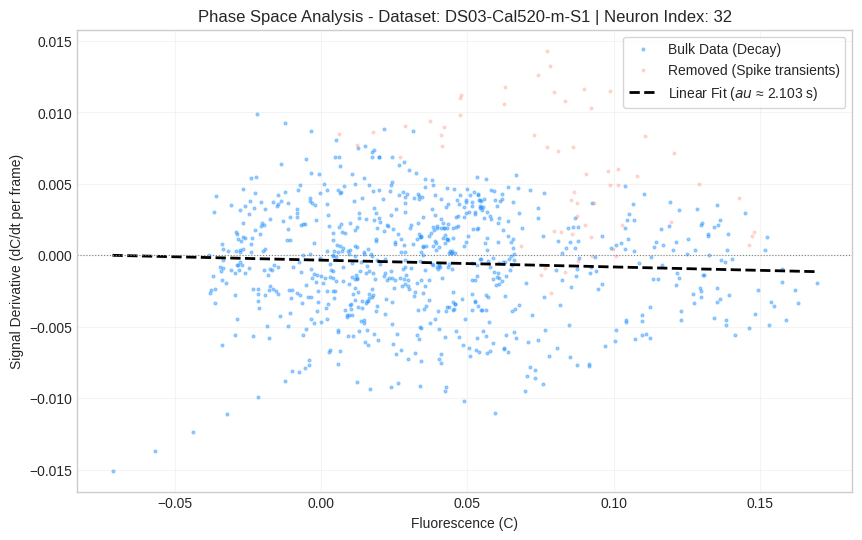

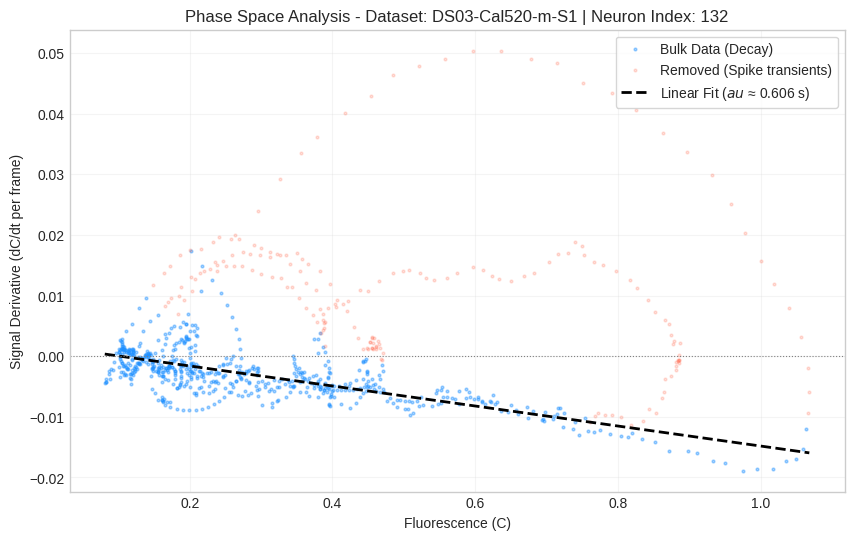

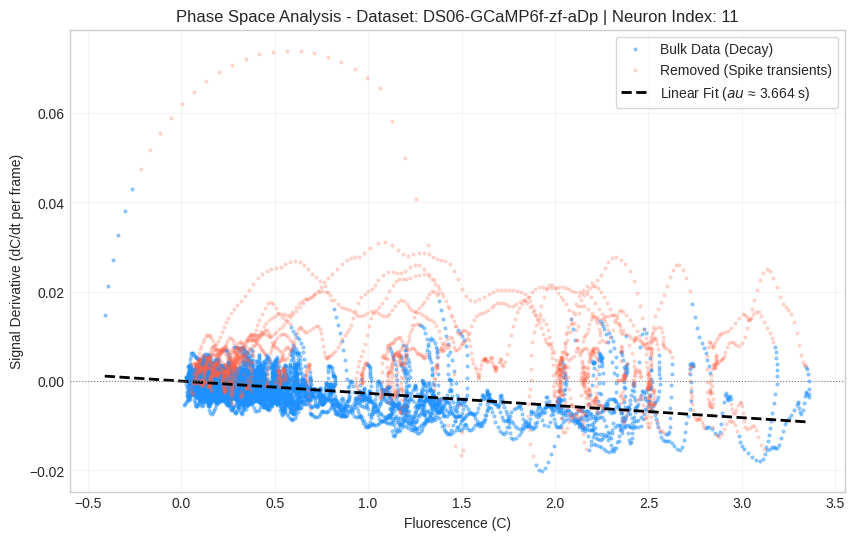

In [10]:

# --- CONFIGURATION ---
# Enter the indices of the neurons you want to check.
# These correspond to the order in your 'upsampled_results' list.
# (Example: [0, 1, 2] to see the first three neurons)
selected_indices = [100, 200, 300] 

# Analysis Parameters (Consistent with your previous table)
window_len = 51
poly_order = 3
cut_win = 10
new_rate = 100 # Hz

for list_idx in selected_indices:
    if list_idx >= len(upsampled_results):
        print(f"Index {list_idx} is out of range.")
        continue
        
    res = upsampled_results[list_idx]
    u_sig = res['signal'].copy()
    u_spk = res['spikes']
    
    # 1. Handle NaNs in signal
    if np.any(np.isnan(u_sig)):
        mask = np.isnan(u_sig)
        if not np.all(mask):
            u_sig[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), u_sig[~mask])
        else: continue

    # 2. Smooth Signal and Calculate Derivative
    sig_smooth = savgol_filter(u_sig, window_length=window_len, polyorder=poly_order, deriv=0)
    der_smooth = savgol_filter(u_sig, window_length=window_len, polyorder=poly_order, deriv=1)
    
    # 3. Identify and Cut Spike Transients
    # sig_fit and der_fit are the points remaining after removing the spike windows
    sig_fit, der_fit, removed_mask = rate_analysis.cut_spikes(u_spk, sig_smooth, der_smooth, win_len=cut_win)
    
    # 4. Standard Linear Fit (No RANSAC)
    try:
        if len(sig_fit) > 2:
            slope, intercept = np.polyfit(sig_fit, der_fit, 1)
            # Convert slope (per frame) to tau in seconds: tau = -1 / (slope * FPS)
            tau_sec = -1.0 / (slope * new_rate) if slope < 0 else np.nan
        else:
            tau_sec = np.nan
    except:
        tau_sec = np.nan

    # 5. Plotting Phase Space
    plt.figure(figsize=(10, 6))
    
    # Plot "Bulk" points used for the fit (Decay)
    plt.scatter(sig_smooth[~removed_mask], der_smooth[~removed_mask], 
                s=4, color='dodgerblue', alpha=0.4, label='Bulk Data (Decay)')
    
    # Plot "Cut" points removed near spikes
    plt.scatter(sig_smooth[removed_mask], der_smooth[removed_mask], 
                s=4, color='tomato', alpha=0.2, label='Removed (Spike transients)')
    
    # Plot the Regression Line
    if not np.isnan(tau_sec):
        x_range = np.array([np.min(sig_smooth), np.max(sig_smooth)])
        y_line = slope * x_range + intercept
        plt.plot(x_range, y_line, color='black', linestyle='--', linewidth=2, 
                 label=f'Linear Fit ($\tau$ ≈ {tau_sec:.3f} s)')
    
    plt.title(f"Phase Space Analysis - Dataset: {res['dataset']} | Neuron Index: {res['neuron_idx']}")
    plt.xlabel("Fluorescence (C)")
    plt.ylabel("Signal Derivative (dC/dt per frame)")
    plt.axhline(0, color='gray', linewidth=0.8, linestyle=':')
    plt.legend(loc='upper right', frameon=True)
    plt.grid(alpha=0.2)
    plt.show()

In [5]:
# Analysis Settings
window_len = 51
poly_order = 3
cut_win = 10
new_rate = 100 

results = []

print("Generating final summary table with Reconstruction Correlation...")

for res in upsampled_results:
    u_sig = res['signal'].copy()
    u_spk = res['spikes']
    
    # 1. Standardize Signal (Handle NaNs)
    if np.any(np.isnan(u_sig)):
        mask = np.isnan(u_sig)
        if not np.all(mask):
            u_sig[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), u_sig[~mask])
        else: 
            continue

    # 2. Derivative & Smoothing
    if len(u_sig) < window_len: 
        continue
    sig_smooth = savgol_filter(u_sig, window_length=window_len, polyorder=poly_order, deriv=0)
    der_smooth = savgol_filter(u_sig, window_length=window_len, polyorder=poly_order, deriv=1)
    
    # 3. Tau Estimation (in frames)
    sig_fit, der_fit, _ = rate_analysis.cut_spikes(u_spk, sig_smooth, der_smooth, win_len=cut_win)
    
    try:
        if len(sig_fit) > 2:
            slope, _ = np.polyfit(sig_fit, der_fit, 1)
            tau_frames = -1.0 / slope if slope < 0 else np.nan
        else: 
            tau_frames = np.nan
    except: 
        tau_frames = np.nan
        
    # 4. Calcium Reconstruction Correlation
    # Now calls the updated functions in rate_analysis
    corr_val = rate_analysis.calculate_reconstruction_corr(u_sig, u_spk, tau_frames)
    
    # 5. CV2 Calculation
    cv2_val = rate_analysis.calculate_cv2(u_spk)
    
    # 6. Metadata Calculation
    sig_len = len(u_sig)
    duration = sig_len / new_rate
    
    # Robust spike counting (works for indices or binary vectors)
    n_spikes = len(u_spk) if len(u_spk) != sig_len else np.sum(u_spk > 0.5)
    
    results.append({
        'Dataset': res['dataset'],
        'Neuron_Idx': res['neuron_idx'],
        'Signal_Length': sig_len,
        'Duration_s': round(duration, 2),
        'Num_Spikes': int(n_spikes),
        'Estimated_Tau_s': round(tau_frames / new_rate, 4) if not np.isnan(tau_frames) else "N/A",
        'Recon_Corr': round(corr_val, 4) if not np.isnan(corr_val) else "N/A",
        'CV2': round(cv2_val, 4) if not np.isnan(cv2_val) else "N/A",
        'Firing_Rate_Hz': round(n_spikes / duration, 2) if duration > 0 else 0
    })

# Create and Sort Table
df_final = pd.DataFrame(results).sort_values(by='Num_Spikes', ascending=False)

# Display Table
pd.set_option('display.max_rows', None)
display(HTML("<h3>Final Analysis (Sorted by Spike Count)</h3>"))
display(HTML("<div style='height: 500px; overflow: auto; width: 100%; border: 1px solid #ddd;'>" + 
             df_final.to_html(index=False) + 
             "</div>"))
pd.reset_option('display.max_rows')

# Global Summary Statistics
valid_numeric = df_final[['Estimated_Tau_s', 'Recon_Corr', 'CV2']].apply(pd.to_numeric, errors='coerce')
print("\n--- Global Analysis Summary ---")
print(f"Total Neurons: {len(df_final)}")
print(valid_numeric.describe().loc[['mean', 'std', '50%']].round(4))

Generating final summary table with Reconstruction Correlation...


/home/mjoudy/Documents/codes/Cascade/spikes_proxy_funcs/rate_analysis.py:120: RuntimeWarning: invalid value encountered in divide
  return np.mean(2 * np.abs(isi[1:] - isi[:-1]) / (isi[1:] + isi[:-1]))
/home/mjoudy/miniconda3/envs/phd_conda/lib/python3.12/site-packages/numpy/lib/_polynomial_impl.py:665: RuntimeWarning: invalid value encountered in divide
  lhs /= scale


 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  5 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value


Dataset,Neuron_Idx,Signal_Length,Duration_s,Num_Spikes,Estimated_Tau_s,Recon_Corr,CV2,Firing_Rate_Hz
DS25-GCaMP6f-m-SST-V1,2,325586,3255.86,18890,7.1696,0.7207,0.7437,5.80
DS26-GCaMP6f-m-VIP-V1,47,216679,2166.79,17398,0.5653,0.7764,0.8858,8.03
DS24-GCaMP6f-m-PV-V1,40,64895,648.95,14400,1.4821,0.9295,0.1221,22.19
DS24-GCaMP6f-m-PV-V1,34,131494,1314.94,14358,1.3374,0.8789,0.2672,10.92
DS24-GCaMP6f-m-PV-V1,7,68498,684.98,14198,4.0144,0.8443,0.119,20.73
DS25-GCaMP6f-m-SST-V1,25,99593,995.93,12213,2.1406,0.9066,0.6085,12.26
DS24-GCaMP6f-m-PV-V1,37,75335,753.35,12103,1.6218,0.8402,0.1728,16.07
DS24-GCaMP6f-m-PV-V1,20,80563,805.63,11738,1.8029,0.8707,0.4189,14.57
DS25-GCaMP6f-m-SST-V1,49,121919,1219.19,11729,1.6303,0.7752,0.6498,9.62
DS26-GCaMP6f-m-VIP-V1,16,96878,968.78,10504,0.7737,0.9449,0.4467,10.84



--- Global Analysis Summary ---
Total Neurons: 1157
      Estimated_Tau_s  Recon_Corr     CV2
mean           5.4619      0.6716  1.1044
std           30.3806      0.2853  0.5138
50%            1.4085      0.7833  1.1614


Cleared 0 previous images from 'reconstruction_analysis'.
Starting processing for 1157 neurons...


KeyboardInterrupt: 

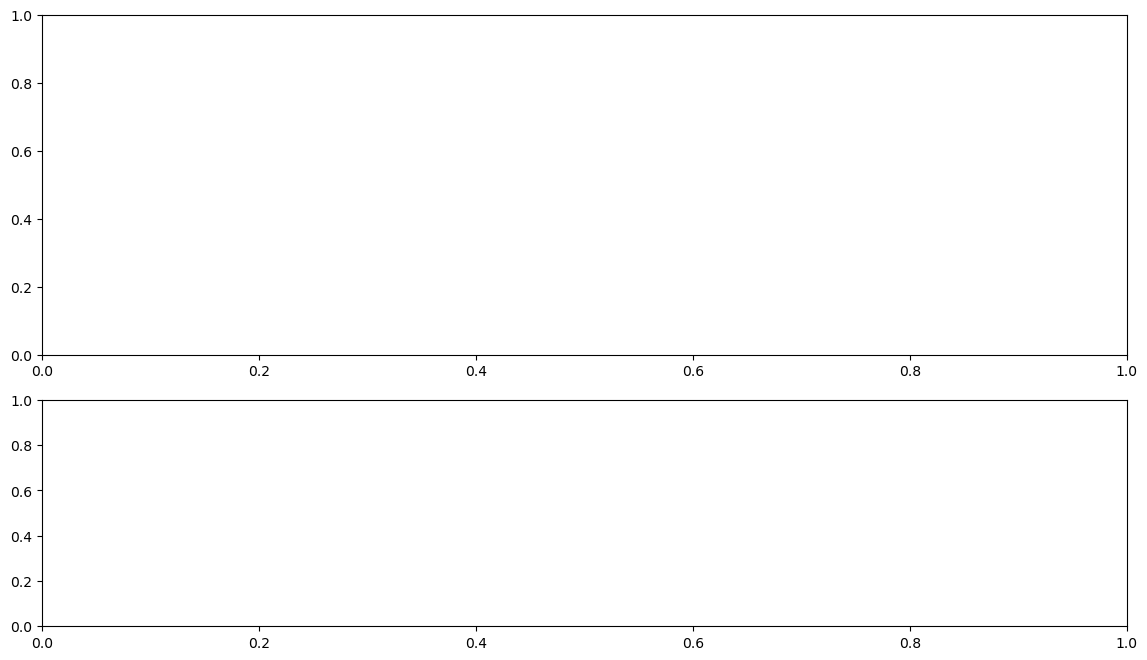

In [5]:
import os
import glob
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, HTML
from scipy.signal import savgol_filter

# --- 1. Setup & Clear Folder ---
output_dir = "reconstruction_analysis"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
else:
    # Remove all previous images to ensure a fresh start
    files = glob.glob(os.path.join(output_dir, "*.png"))
    for f in files:
        os.remove(f)
    print(f"Cleared {len(files)} previous images from '{output_dir}'.")

# Analysis Settings
window_len, poly_order, cut_win, new_rate = 51, 3, 10, 100 
results = []
total_neurons = len(upsampled_results)

print(f"Starting processing for {total_neurons} neurons...")

for i, res in enumerate(upsampled_results):
    # --- Progress Output ---
    remaining = total_neurons - (i + 1)
    print(f"Processing neuron {i+1}/{total_neurons} | Remaining: {remaining}    ", end='\r')
    
    u_sig, u_spk = res['signal'].copy(), res['spikes']
    
    # Standardize Signal (Handle NaNs)
    if np.any(np.isnan(u_sig)):
        mask = np.isnan(u_sig)
        if not np.all(mask):
            u_sig[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), u_sig[~mask])
        else: continue

    # Tau Estimation
    sig_smooth = savgol_filter(u_sig, window_length=window_len, polyorder=poly_order, deriv=0)
    der_smooth = savgol_filter(u_sig, window_length=window_len, polyorder=poly_order, deriv=1)
    sig_fit, der_fit, _ = rate_analysis.cut_spikes(u_spk, sig_smooth, der_smooth, win_len=cut_win)
    
    try:
        slope_fit, _ = np.polyfit(sig_fit, der_fit, 1) if len(sig_fit) > 2 else (np.nan, 0)
        tau_f = -1.0 / slope_fit if slope_fit < 0 else np.nan
    except: tau_f = np.nan
        
    # --- 2. Reconstruction Calculations (Using functions in rate_analysis.py) ---
    c_corr = rate_analysis.calculate_reconstruction_corr(u_sig, u_spk, tau_f)
    recon_calcium = rate_analysis.reconstruct_calcium(u_spk, tau_f, len(u_sig))
    
    s_corr = rate_analysis.calculate_spike_correlation(u_sig, u_spk, tau_f)
    recon_spks = rate_analysis.reconstruct_spikes(u_sig, tau_f)
    
    cs_slope = rate_analysis.calculate_cumsum_slope(recon_spks, new_rate)
    
    # --- 3. 3-Panel Visualization ---
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True, 
                                       gridspec_kw={'height_ratios': [3, 2, 1]})
    time_axis = np.arange(len(u_sig)) / new_rate
    
    # Panel 1: Calcium Signal
    ax1.plot(time_axis, u_sig, color='gray', alpha=0.4, label='Raw Fluorescence')
    if recon_calcium is not None and not np.all(recon_calcium == 0):
        rc_norm = (recon_calcium - np.min(recon_calcium)) / (np.max(recon_calcium) - np.min(recon_calcium) + 1e-9)
        rc_scaled = rc_norm * (np.max(u_sig) - np.min(u_sig)) + np.min(u_sig)
        ax1.plot(time_axis, rc_scaled, color='crimson', label=f'Recon Calcium (r={c_corr:.2f})')
    ax1.set_ylabel("Fluorescence")
    ax1.legend(loc='upper right')
    ax1.set_title(f"Dataset: {res['dataset']} | Neuron {res['neuron_idx']} | Tau: {tau_f/new_rate if not np.isnan(tau_f) else 0:.3f}s")

    # Panel 2: Spike Reconstruction
    ax2.plot(time_axis, recon_spks, color='darkorange', label=f'Deconvolved Spikes (r={s_corr:.2f})')
    ax2.set_ylabel("Spike Prob.")
    ax2.legend(loc='upper right')

    # Panel 3: Ground Truth Spike Raster
    if len(u_spk) == len(u_sig):
        spike_times = time_axis[u_spk > 0.5]
    else:
        spike_times = np.array(u_spk) / new_rate
    
    ax3.eventplot(spike_times, orientation='horizontal', lineoffsets=0, 
                  linelengths=0.8, colors='black', label='Ground Truth Spikes')
    ax3.set_yticks([]) 
    ax3.set_ylabel("Events")
    ax3.set_xlabel("Time (s)")
    ax3.legend(loc='upper right')
    
    plt.tight_layout()
    
    # Save precisely one file per neuron
    filename = f"{res['dataset']}_n{res['neuron_idx']}.png"
    plt.savefig(os.path.join(output_dir, filename))
    plt.close()

    # --- 4. Logging ---
    n_spikes = len(u_spk) if len(u_spk) != len(u_sig) else np.sum(u_spk > 0.5)
    results.append({
        'Dataset': res['dataset'], 'Neuron': res['neuron_idx'], 'Spikes': int(n_spikes),
        'Tau_s': round(tau_f/new_rate, 3) if not np.isnan(tau_f) else "N/A",
        'Ca_Corr': round(c_corr, 3) if not np.isnan(c_corr) else "N/A",
        'Spike_Corr': round(s_corr, 3) if not np.isnan(s_corr) else "N/A",
        'Cumsum_Slope': round(cs_slope, 3)
    })

print(f"\nProcessing complete! All plots saved to '{output_dir}'.")

# Final Table Display
df_final = pd.DataFrame(results).sort_values(by='Spikes', ascending=False)
display(HTML(f"<h3>Analysis Results (Images in /{output_dir})</h3>"))
display(HTML("<div style='height: 400px; overflow: auto;'>" + df_final.to_html(index=False) + "</div>"))